# WarpKriging with neural monotone warping (R)

The **neural_mono** warp uses a small monotone neural network to learn a flexible
monotone transformation of each input. The network has $H$ hidden units (default 8).

Steps:
1. Install rlibkriging (run once)
2. Load rlibkriging
3. Define the Branin function and plot it
4. Build a space-filling design and evaluate it
5. Fit a `WarpKriging` model
6. Predict on a fine grid and plot mean + uncertainty
7. Inspect model parameters

## 0. Installation (run once)

Build the C++ core and the R binding from source.
Requires: `cmake`, a C++ compiler, and R development headers.

The script `tools/r-linux-macos/build.sh` calls `tools/linux-macos/build.sh`
to build the C++ core, then runs `make` in `bindings/R` to compile and install
**rlibkriging** into `bindings/R/Rlibs`.

In [1]:
# Run this cell once to build and install rlibkriging.
# Skip if already built (bindings/R/Rlibs/rlibkriging exists).
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
rlibs     <- file.path(repo_root, "bindings", "R", "Rlibs", "rlibkriging")

if (!dir.exists(rlibs)) {
  message("Building rlibkriging from source…")
  ret <- system(paste0("cd '", repo_root, "' && bash tools/r-linux-macos/build.sh"))
  if (ret != 0) stop("Build failed — check compiler and cmake installation.")
} else {
  message("rlibkriging already built, skipping.")
}

rlibkriging already built, skipping.



## 1. Load rlibkriging

In [1]:
repo_root <- normalizePath(file.path(getwd(), "../.."), mustWork = FALSE)
lib_path  <- file.path(repo_root, "bindings", "R", "Rlibs")
library(rlibkriging, lib.loc = lib_path)


Attachement du package : ‘rlibkriging’




L'objet suivant est masqué depuis ‘package:stats’:

    kernel




Les objets suivants sont masqués depuis ‘package:base’:

    beta, load, save




## 2. Branin function

The Branin function is a standard benchmark for surrogate modelling, defined on $[0,1]^2$
(rescaled from its canonical domain $[-5, 10] \times [0, 15]$).
It has three global minima.

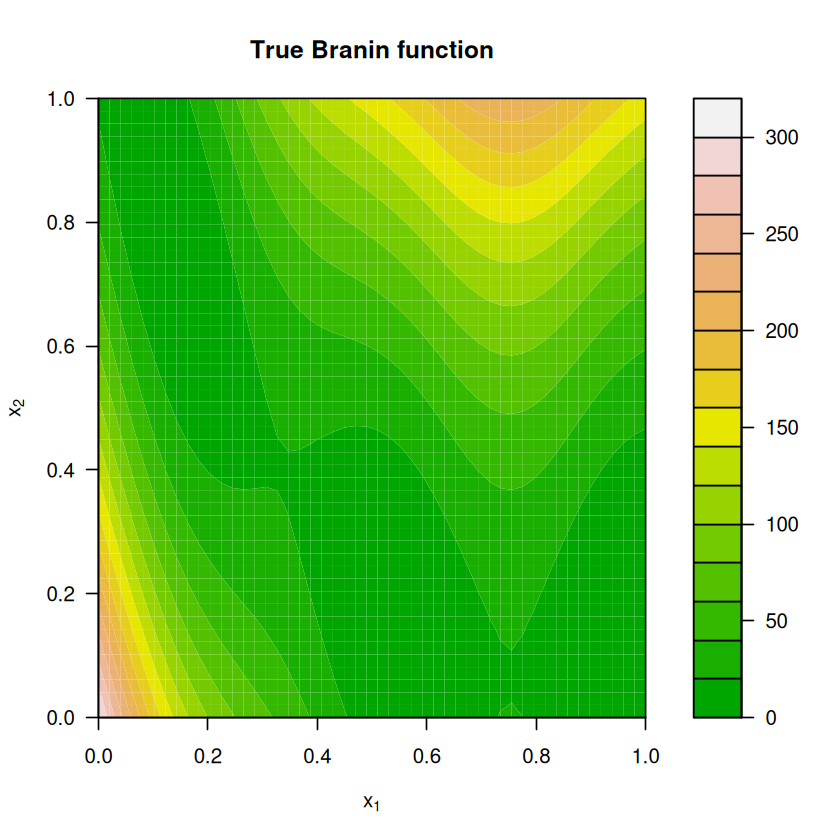

In [2]:
branin <- function(x) {
  if (!is.matrix(x)) x <- matrix(x, nrow = 1)
  x1 <- x[, 1] * 15 - 5
  x2 <- x[, 2] * 15
  (x2 - 5 / (4 * pi^2) * x1^2 + 5 / pi * x1 - 6)^2 +
    10 * (1 - 1 / (8 * pi)) * cos(x1) + 10
}

# Visualise true function on a 50x50 grid
grid_x <- seq(0, 1, length.out = 50)
grid   <- as.matrix(expand.grid(x1 = grid_x, x2 = grid_x))
z_true <- matrix(branin(grid), 50, 50)

filled.contour(
  grid_x, grid_x, z_true,
  color.palette = terrain.colors,
  main = "True Branin function",
  xlab = expression(x[1]), ylab = expression(x[2])
)

## 3. Design of experiments

We sample $n = 30$ points using a Latin Hypercube Design.

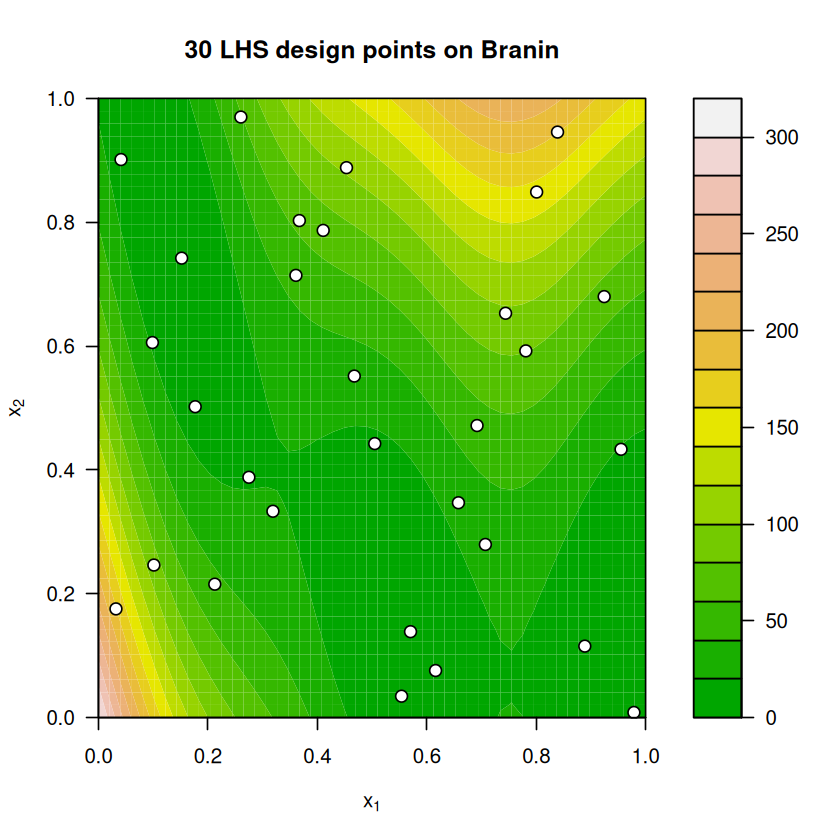

In [3]:
set.seed(42)
n <- 30
lhs <- function(n, d) {
  X <- matrix(NA, n, d)
  for (j in seq_len(d))
    X[, j] <- (sample(n) - runif(n)) / n
  X
}
X <- lhs(n, 2)
y <- branin(X)

filled.contour(
  grid_x, grid_x, z_true,
  color.palette = terrain.colors,
  main = paste(n, "LHS design points on Branin"),
  xlab = expression(x[1]), ylab = expression(x[2]),
  plot.axes = {
    axis(1); axis(2)
    points(X[, 1], X[, 2], pch = 21, bg = "white", cex = 1.2)
  }
)

## 4. Fit a WarpKriging model (`neural_mono`)

We use `warping = c('neural_mono(8)', 'neural_mono(8)')` — one warp per input dimension.

In [4]:
wk <- WarpKriging(
  y, X,
  warping = c('neural_mono(8)', 'neural_mono(8)'),
  kernel = "matern5_2",
  optim = "BFGS+Adam",
  parameters = list(max_iter_adam = '300')
)
print(wk)

* WarpKriging
  - kernel:      matern5_2
  - regmodel:    constant
  - normalize:   false
  - n obs:       30
  - d input:     2
  - d features:  2
  - warpings:
      x0: "neural_mono(8)"  →  NeuralMono(H=8, 25 params)
      x1: "neural_mono(8)"  →  NeuralMono(H=8, 25 params)
  - sigma2:      1.14696e+06
  - theta:          5.2230e+01   2.1397e+02
  - beta:           1.0985e+03
  - LL:          -120.986
  - total warp params: 50


## 5. Predict on a fine grid

`predict()` returns the posterior mean and standard deviation at new points.

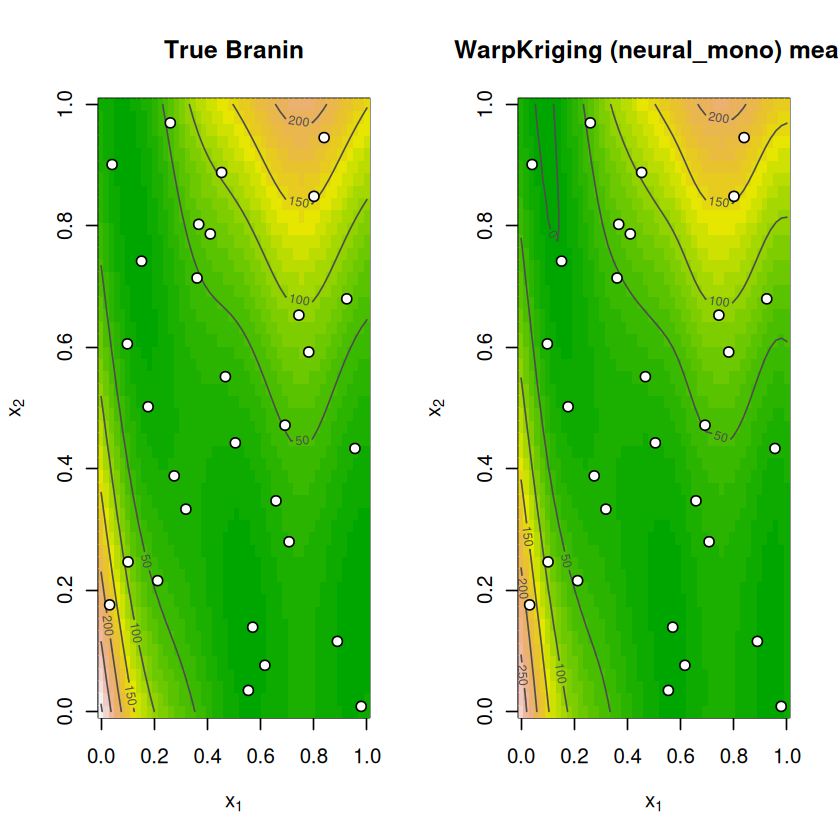

In [5]:
p <- predict(wk, grid, return_stdev = TRUE)
z_mean <- matrix(p$mean,  50, 50)
z_sd   <- matrix(p$stdev, 50, 50)

brks <- seq(min(z_true, z_mean), max(z_true, z_mean), length.out = 30)
cols <- terrain.colors(length(brks) - 1)

par(mfrow = c(1, 2))

image(grid_x, grid_x, z_true, breaks = brks, col = cols,
      main = "True Branin", xlab = expression(x[1]), ylab = expression(x[2]))
contour(grid_x, grid_x, z_true, add = TRUE, col = "grey30", nlevels = 10)
points(X[, 1], X[, 2], pch = 21, bg = "white")

image(grid_x, grid_x, z_mean, breaks = brks, col = cols,
      main = "WarpKriging (neural_mono) mean", xlab = expression(x[1]), ylab = expression(x[2]))
contour(grid_x, grid_x, z_mean, add = TRUE, col = "grey30", nlevels = 10)
points(X[, 1], X[, 2], pch = 21, bg = "white")

par(mfrow = c(1, 1))

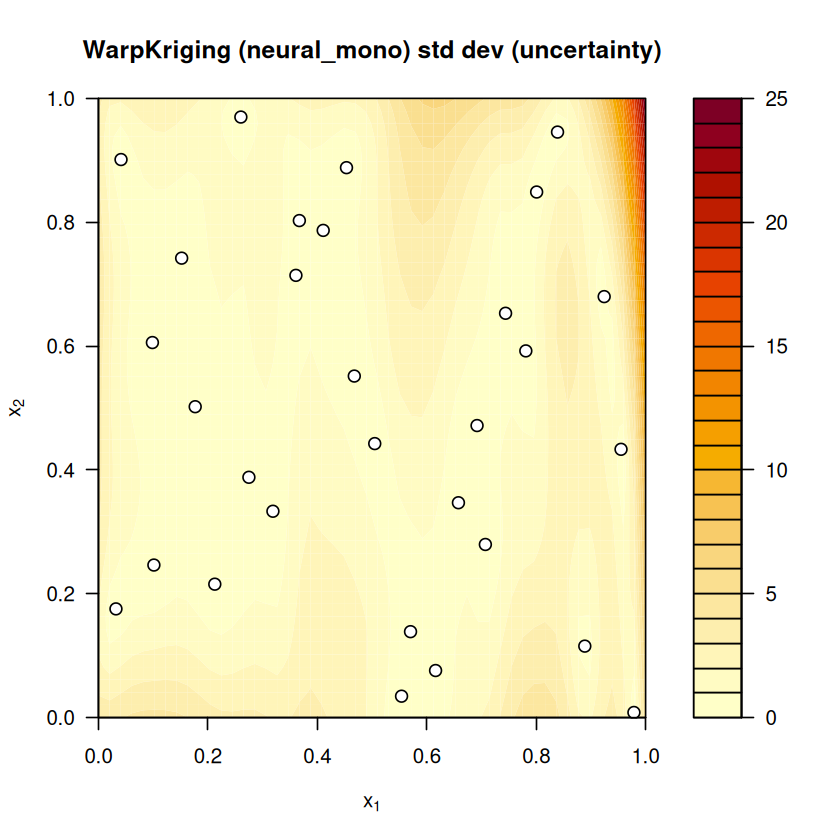

In [6]:
# Posterior standard deviation (uncertainty)
filled.contour(
  grid_x, grid_x, z_sd,
  color.palette = function(n) hcl.colors(n, "YlOrRd", rev = TRUE),
  main = "WarpKriging (neural_mono) std dev (uncertainty)",
  xlab = expression(x[1]), ylab = expression(x[2]),
  plot.axes = {
    axis(1); axis(2)
    points(X[, 1], X[, 2], pch = 21, bg = "white", cex = 1.2)
  }
)

## 6. Model inspection

Key fitted parameters: length-scales $\theta$, variance $\sigma^2$, log-likelihood, and warping specification.

In [7]:
cat("Kernel       :", kernel(wk), "\n")
cat("Theta (range):", round(theta(wk), 4), "\n")
cat("Sigma2       :", round(sigma2(wk), 4), "\n")
cat("LogLikelihood:", round(logLikelihood(wk), 4), "\n")
cat("Warping      :", warping(wk), "\n")

Kernel       : matern5_2 


Theta (range): 52.2296 213.9725 


Sigma2       : 1146964 


LogLikelihood: -120.9857 


Warping      : neural_mono(8) neural_mono(8) 
